   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70          0.0             1.9      0.076   
1            7.8              0.88          0.0             2.6      0.098   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   

   alcohol  quality  
0      9.4        5  
1      9.8        5  

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Target distribution (0=bad, 1=good):
good
0    1382
1     217
Name: count, dtype: int64

Boolean indexing result: [1 4]

R

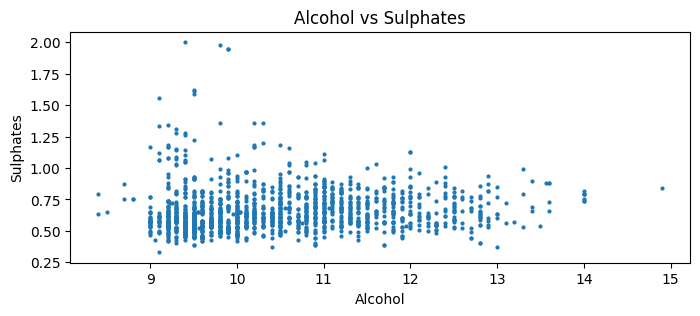

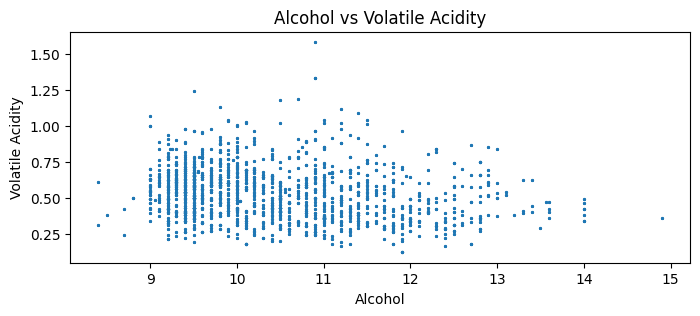

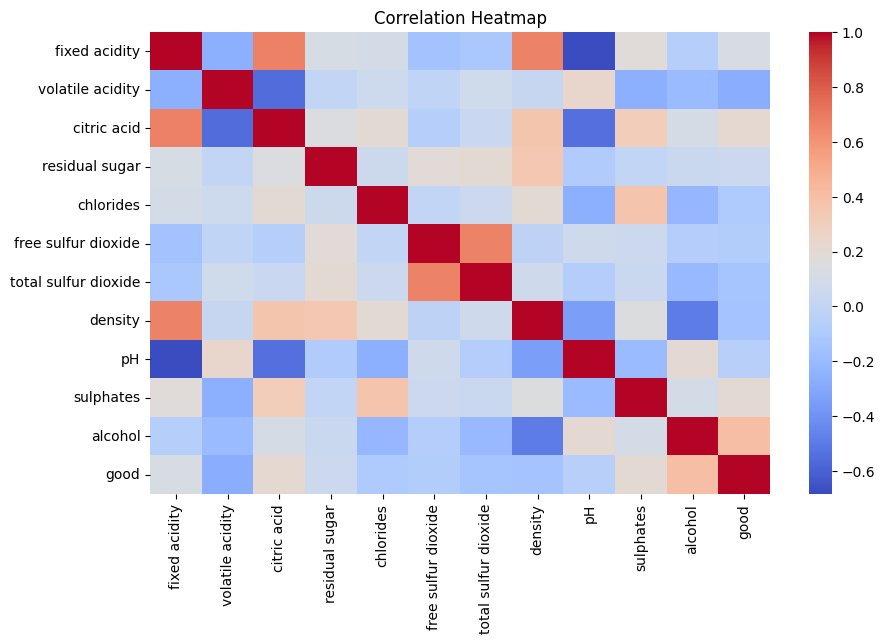


📊 Logistic Regression Results
Accuracy:  0.8125
Recall:    0.7907
Precision: 0.4000
F1 Score:  0.5312
AUC:       0.8824


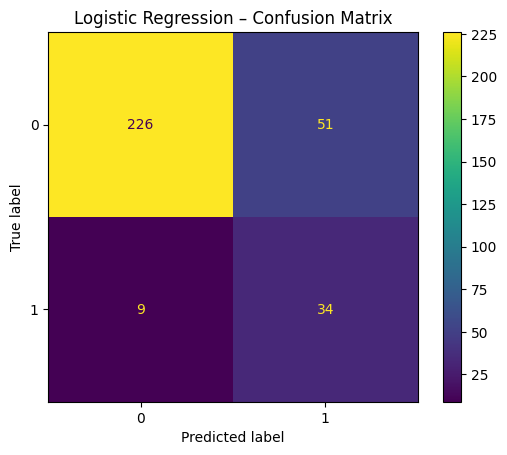


📊 Linear SVM Results
Accuracy:  0.8094
Recall:    0.8140
Precision: 0.3977
F1 Score:  0.5344
AUC:       0.8844


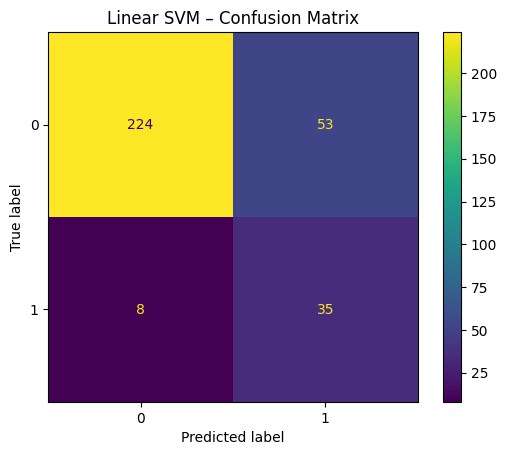


Best Decision Tree params: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV AUC: 0.8443495950416366

📊 Decision Tree (tuned) Results
Accuracy:  0.8187
Recall:    0.8140
Precision: 0.4118
F1 Score:  0.5469
AUC:       0.8489


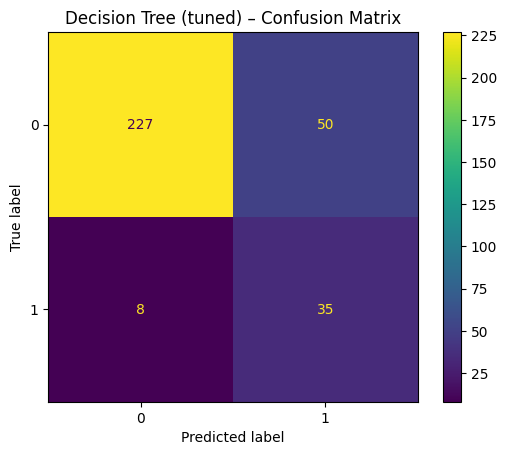

In [1]:
# 📌 Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

# -----------------------------
# 1) Load & quick checks
# -----------------------------
df = pd.read_csv("data/winequality-red.csv")  # change path if needed
print(df.head(2))

print("\nMissing values per column:")
print(df.isna().sum())

# -----------------------------
# 2) Make binary target (good/1, bad/0)
# -----------------------------
df['good'] = (df['quality'] >= 7).astype(int)
print("\nTarget distribution (0=bad, 1=good):")
print(df['good'].value_counts())

# Drop original 'quality' to avoid leakage
df = df.drop(columns=['quality'])

# -----------------------------
# 3) Numpy / filtering snippets (to mirror your template)
# -----------------------------
a = np.array([1, 2, 3, 4])
b = np.array([True, False, False, True])
print("\nBoolean indexing result:", a[b])

print("\nRows with alcohol > 12 and pH <= 3.2:")
print(df[(df['alcohol'] > 12) & (df['pH'] <= 3.2)].head())

# -----------------------------
# 4) Simple viz / correlation
# -----------------------------
df_sorted = df.sort_values('alcohol').reset_index(drop=True)

plt.figure(figsize=(8, 3))
plt.plot(df_sorted['alcohol'], df_sorted['sulphates'], 'o', ms=2)
plt.title("Alcohol vs Sulphates")
plt.xlabel("Alcohol")
plt.ylabel("Sulphates")
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(df_sorted['alcohol'], df_sorted['volatile acidity'], '*', ms=2)
plt.title("Alcohol vs Volatile Acidity")
plt.xlabel("Alcohol")
plt.ylabel("Volatile Acidity")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# 5) Train / Test split
# -----------------------------
X = df.drop(columns=['good'])
y = df['good']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# Helper: evaluate & (optionally) plot confusion matrix
# -----------------------------
def evaluate_clf(name, y_true, y_pred, y_score=None):
    print(f"\n📊 {name} Results")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
    if y_score is not None:
        try:
            auc = roc_auc_score(y_true, y_score)
            print(f"AUC:       {auc:.4f}")
        except Exception as e:
            print("AUC not available:", e)

    disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred))
    disp.plot(values_format='d')
    plt.title(f"{name} – Confusion Matrix")
    plt.show()

# -----------------------------
# 6) Logistic Regression (with scaling)
# -----------------------------
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=None))
])
log_pipe.fit(X_train, y_train)

y_pred_log = log_pipe.predict(X_test)
# get probability for ROC/AUC
y_prob_log = log_pipe.predict_proba(X_test)[:, 1]

evaluate_clf("Logistic Regression", y_test, y_pred_log, y_prob_log)

# -----------------------------
# 7) Linear SVM (with scaling)
#    Note: LinearSVC doesn't give proba; use decision_function for ROC/AUC
# -----------------------------
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(max_iter=20000, class_weight="balanced"))
])
svm_pipe.fit(X_train, y_train)

y_pred_svm = svm_pipe.predict(X_test)
# decision_function outputs signed distance; suitable for ROC/AUC
y_score_svm = svm_pipe.decision_function(X_test)

evaluate_clf("Linear SVM", y_test, y_pred_svm, y_score_svm)

# -----------------------------
# 8) Decision Tree + hyperparameter tuning
# -----------------------------
param_grid = {
    "max_depth": [None, 4, 6, 8, 10, 12],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy"]
}
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")
grid = GridSearchCV(
    dt, param_grid, scoring="roc_auc", cv=5, n_jobs=-1, verbose=0
)
grid.fit(X_train, y_train)
best_dt = grid.best_estimator_
print("\nBest Decision Tree params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]
evaluate_clf("Decision Tree (tuned)", y_test, y_pred_dt, y_prob_dt)

# -----------------------------
# 9) Plot ROC curves for all models
# -----------------------------
# fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
# fpr_dt,  tpr_dt,  _ = roc_curve(y_test, y_prob_dt)
# fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)

# plt.figure(figsize=(7, 5))
# plt.plot(fpr_log, tpr_log, label="Logistic Regression")
# plt.plot(fpr_dt,  tpr_dt,  label="Decision Tree (tuned)")
# plt.plot(fpr_svm, tpr_svm, label="Linear SVM")
# plt.plot([0, 1], [0, 1], 'k--', lw=1)
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curves")
# plt.legend()
# plt.grid(True, ls="--", alpha=0.4)
# plt.show()

# # -----------------------------
# # 10) (Optional) Feature importance from Decision Tree
# # -----------------------------
# fi = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=False)
# print("\nTop Feature Importances (Decision Tree):")
# print(fi.head(10))
# fi.plot(kind="bar", figsize=(8, 3), title="Decision Tree Feature Importances")
# plt.tight_layout()
# plt.show()
